In [0]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv('/Volumes/airfly_workspace/default/airfly_insights/flights_cleaned.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# 1. Month (numeric month from Date)
df['Month'] = df['Date'].dt.month

# 2. DayOfWeekNum (use existing DayOfWeek column)
# If DayOfWeek already exists as numeric (1=Mon etc.), just copy or standardize
df['DayOfWeekNum'] = df['DayOfWeek'] - 1  # optional normalization (0=Mon)

# 3. DepHour (extract hour from DepTime)
def extract_hour(x):
    try:
        x = int(x)
        hour = x // 100
        if 0 <= hour < 24:
            return hour
        else:
            return None
    except:
        return None

df['DepHour'] = df['DepTime'].apply(extract_hour)

# 4. Route (Origin–Destination)
df['Route'] = df['Origin'] + '-' + df['Dest']

# Verify new columns
print(df[['Month', 'DayOfWeekNum', 'DepHour', 'Route']].head())


   Month  DayOfWeekNum  DepHour    Route
0      1             3     18.0  IND-BWI
1      1             3     19.0  IND-LAS
2      1             3     16.0  IND-MCO
3      1             3     14.0  IND-PHX
4      1             3     13.0  IND-TPA


In [0]:
# Save the Updated File

df.to_csv('/Volumes/airfly_workspace/default/airfly_insights/flights_cleaned.csv', index=False)
print("Updated cleaned dataset saved successfully.")

Updated cleaned dataset saved successfully.


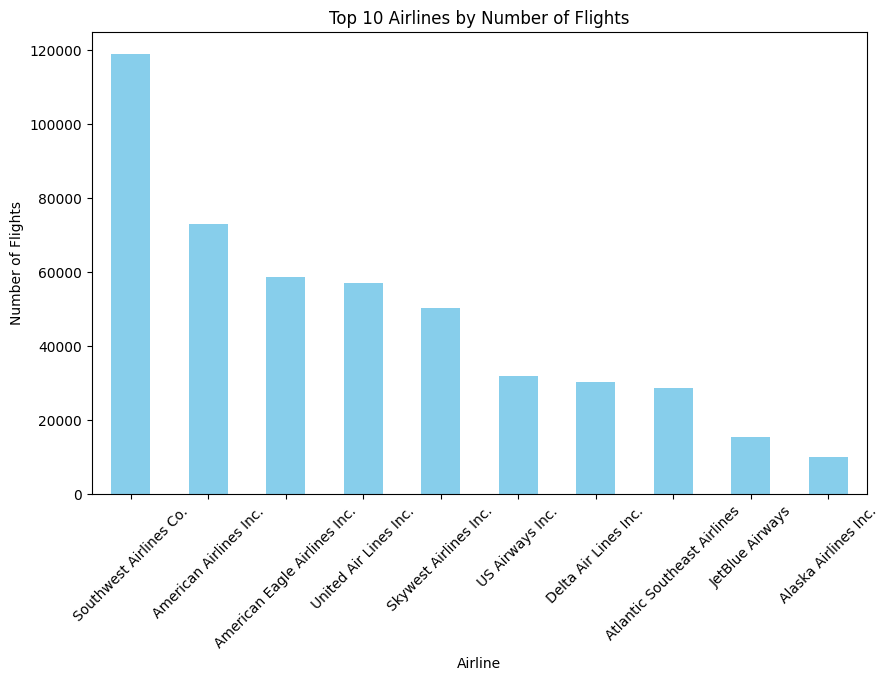

In [0]:
# Top Airlines by Number of Flights

plt.figure(figsize=(10,6))
df['Airline'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Airlines by Number of Flights')
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.show()

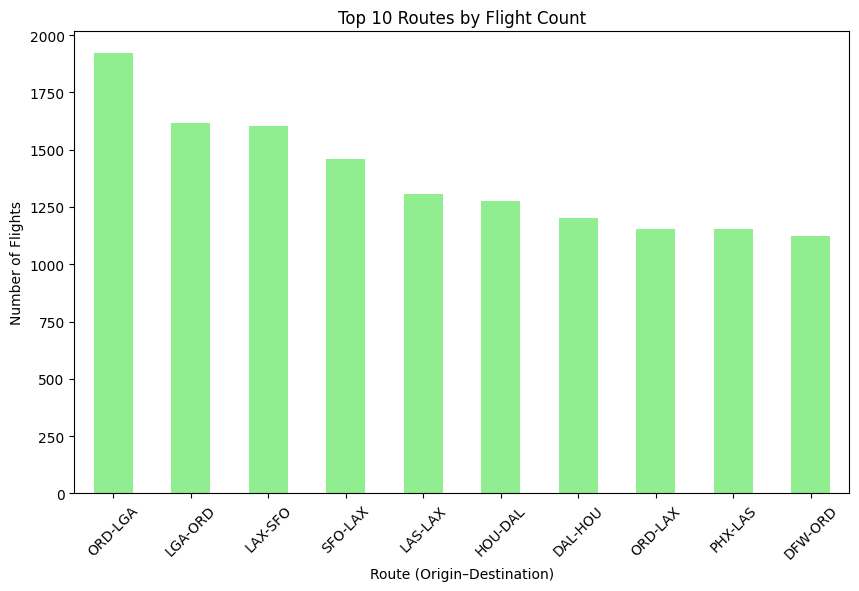

In [0]:
# Top Routes by Flight Volume

plt.figure(figsize=(10,6))
df['Route'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Routes by Flight Count')
plt.xlabel('Route (Origin–Destination)')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.show()

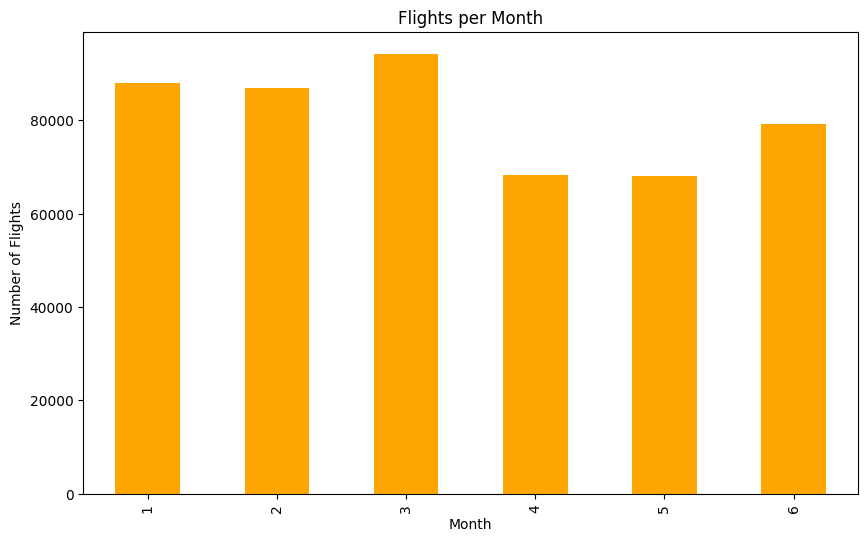

In [0]:
# Busiest Months

plt.figure(figsize=(10,6))
df['Month'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Flights per Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')
plt.show()

/home/spark-3e876ba4-31ff-4552-9638-df/.ipykernel/2393/command-4843110732662892-1103367531:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeekNum', data=df, palette='viridis')


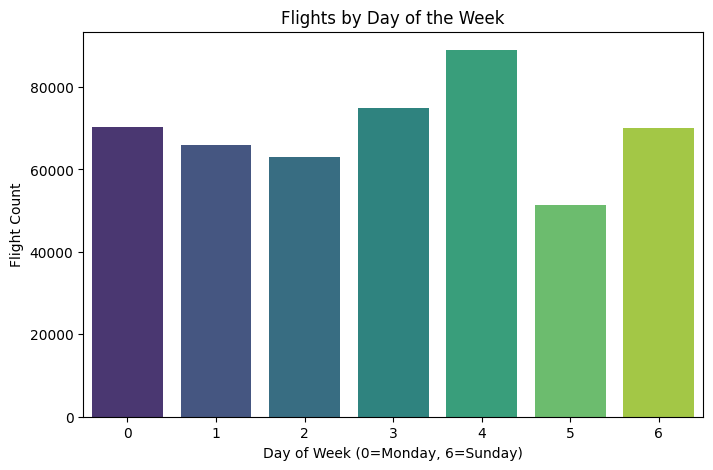

In [0]:
# Flights by Day of Week

plt.figure(figsize=(8,5))
sns.countplot(x='DayOfWeekNum', data=df, palette='viridis')
plt.title('Flights by Day of the Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Flight Count')
plt.show()

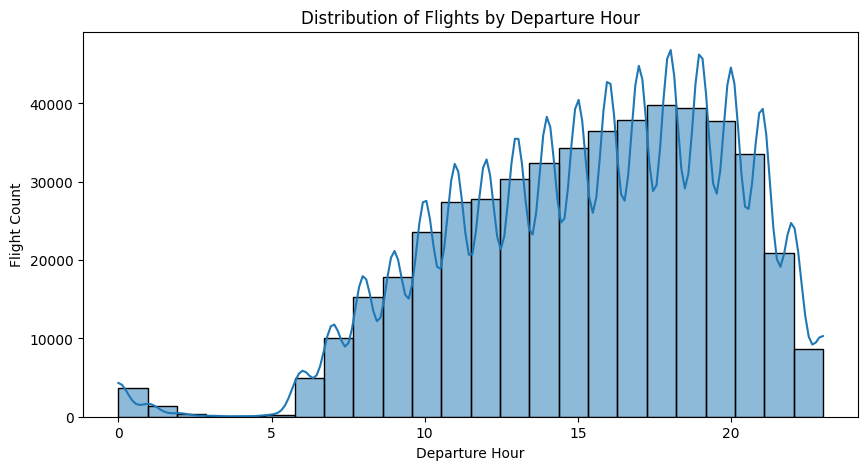

In [0]:
# Departure Hour Distribution

plt.figure(figsize=(10,5))
sns.histplot(df['DepHour'], bins=24, kde=True)
plt.title('Distribution of Flights by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Flight Count')
plt.show()

/home/spark-3e876ba4-31ff-4552-9638-df/.ipykernel/2393/command-4843110732662894-3122582158:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_airports.index, y=top_airports.values, palette='coolwarm')


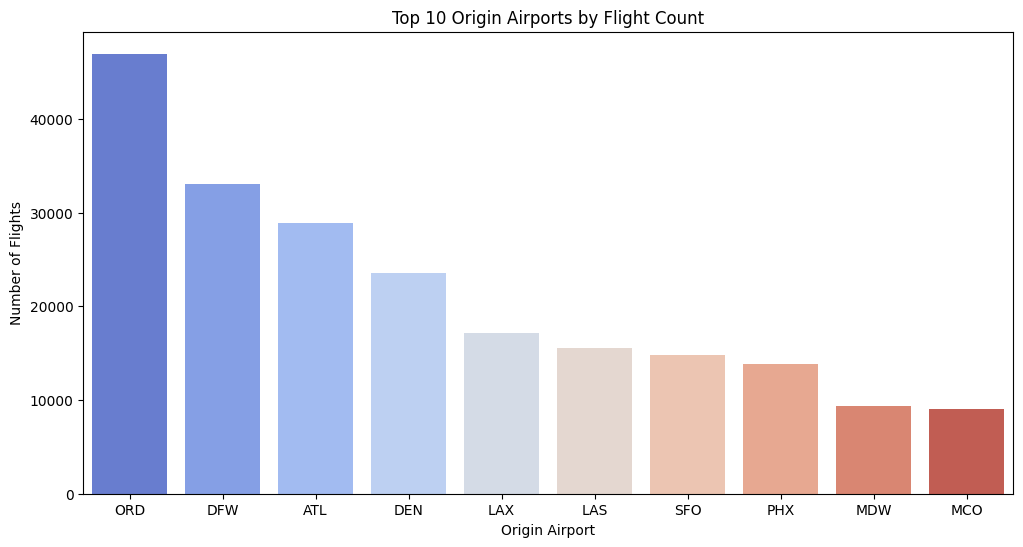

In [0]:
# Flights by Origin Airport

plt.figure(figsize=(12,6))
top_airports = df['Origin'].value_counts().head(10)
sns.barplot(x=top_airports.index, y=top_airports.values, palette='coolwarm')
plt.title('Top 10 Origin Airports by Flight Count')
plt.xlabel('Origin Airport')
plt.ylabel('Number of Flights')
plt.show()

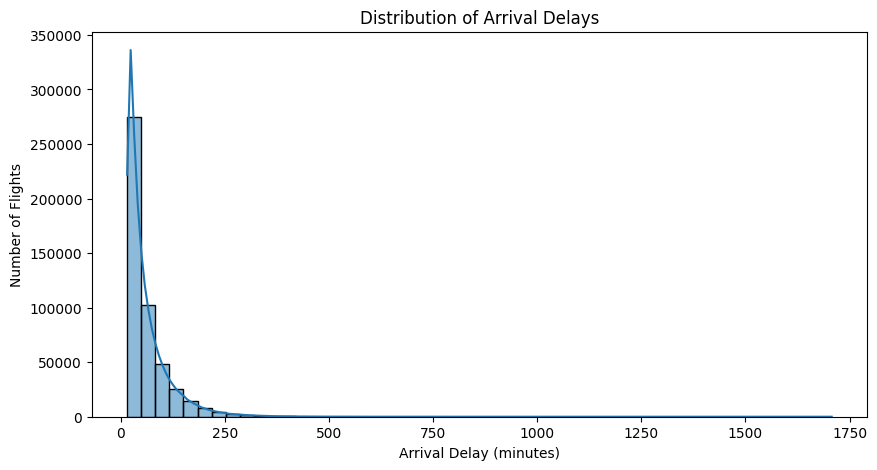

In [0]:
# Distribution of Arrival Delay

plt.figure(figsize=(10,5))
sns.histplot(df['ArrDelay'], bins=50, kde=True)
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Number of Flights')
plt.show()

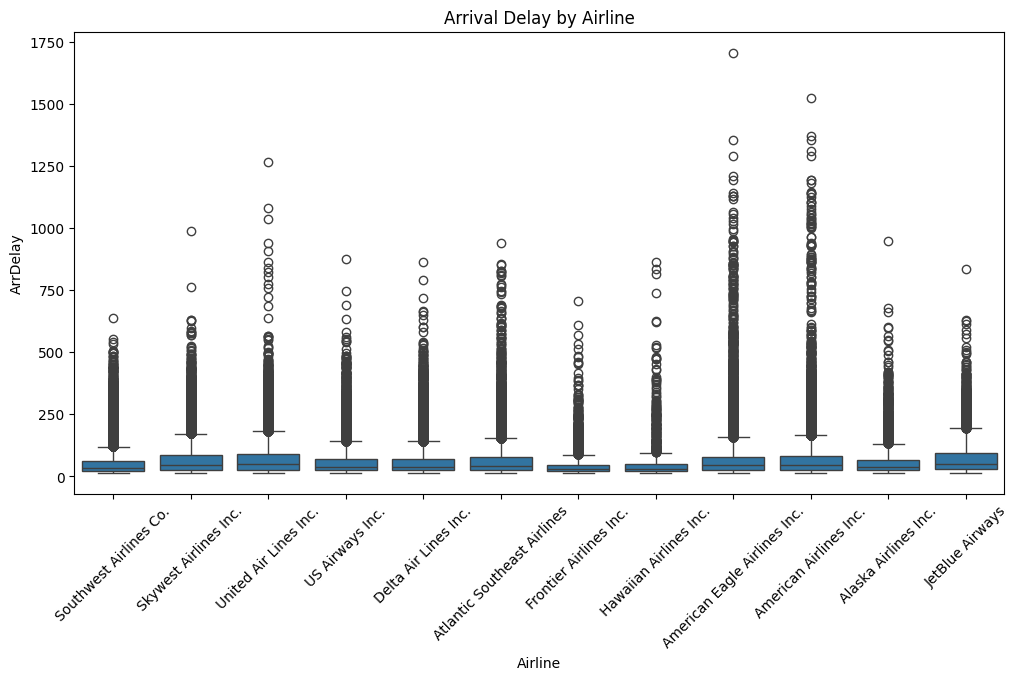

In [0]:
# Boxplot of Arrival Delay by Airline

plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y='ArrDelay', data=df)
plt.title('Arrival Delay by Airline')
plt.xticks(rotation=45)
plt.show()

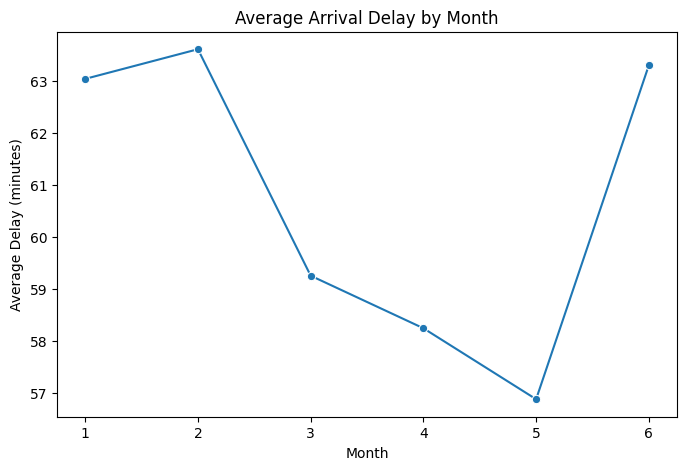

In [0]:
# Average Delay by Month (Line Plot)

monthly_delay = df.groupby('Month')['ArrDelay'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x='Month', y='ArrDelay', data=monthly_delay, marker='o')
plt.title('Average Arrival Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay (minutes)')
plt.show()